In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Electric_Production.csv')

In [5]:
df.describe()

,IPG2211A2N
count,397.000000
mean,88.847218
std,15.387834
min,55.315100
25%,77.105200
50%,89.779500
75%,100.524400
max,129.404800


In [6]:
df.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [ ]:
df.sort_values(by='DATE', inplace=True)
df.set_index('DATE', inplace=True)
df.index = pd.to_datetime(df.index)

In [ ]:
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
import warnings
import matplotlib.dates as mdates

def run_stationary_suites(df,name):
    series=df['IPG2211A2N'].dropna()

    adfuller_result = adfuller(series)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_result  = kpss(series, regression='c')
    pp_result = PhillipsPerron(series)

    adf_verdict = "STATIONARY" if adfuller_result[1] < 0.05 else "NON-STATIONARY"
    kpss_verdict = "STATIONARY" if kpss_result[1] > 0.05 else "NON-STATIONARY"
    pp_verdict = "STATIONARY" if pp_result.pvalue < 0.05 else "NON-STATIONARY"

    plt.figure(figsize=(12,5))

    plt.plot(df.index, df['IPG2211A2N'],label='Electric Production',color='blue')

    plt.xlabel('Date')
    plt.ylabel('Electric Production')
    plt.title(f'{name} Series')

    plt.tight_layout()
    plt.show()

    print(f"Results for {name} Series:")
    print("=" * 30)
    print("ADF TEST:")
    print(f"  P-Value: {adfuller_result[1]:.6f}")
    print(f"  Verdict: {adf_verdict}")
    print("KPSS TEST:")
    print(f"  P-Value: {kpss_result[1]:.6f}")
    print(f"  Verdict: {kpss_verdict}")
    print("Phillips-Perron TEST:")
    print(f"  P-Value: {pp_result.pvalue:.6f}")
    print(f"  Verdict: {pp_verdict}")

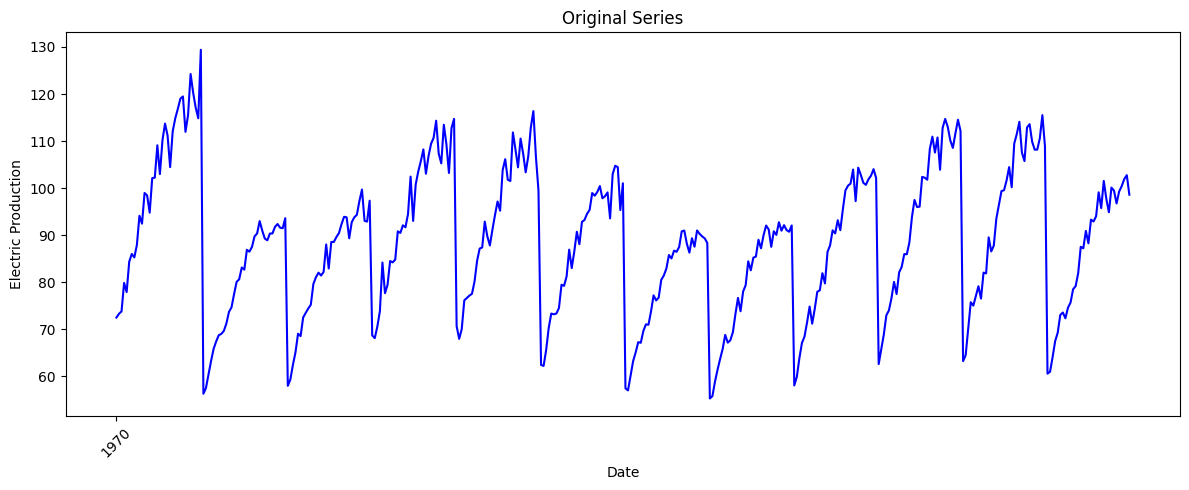

Results for Original Series:
ADF TEST:
  P-Value: 0.000002
  Verdict: STATIONARY
KPSS TEST:
  P-Value: 0.100000
  Verdict: STATIONARY
Phillips-Perron TEST:
  P-Value: 0.000002
  Verdict: STATIONARY


In [82]:
run_stationary_suites(df,'Original')

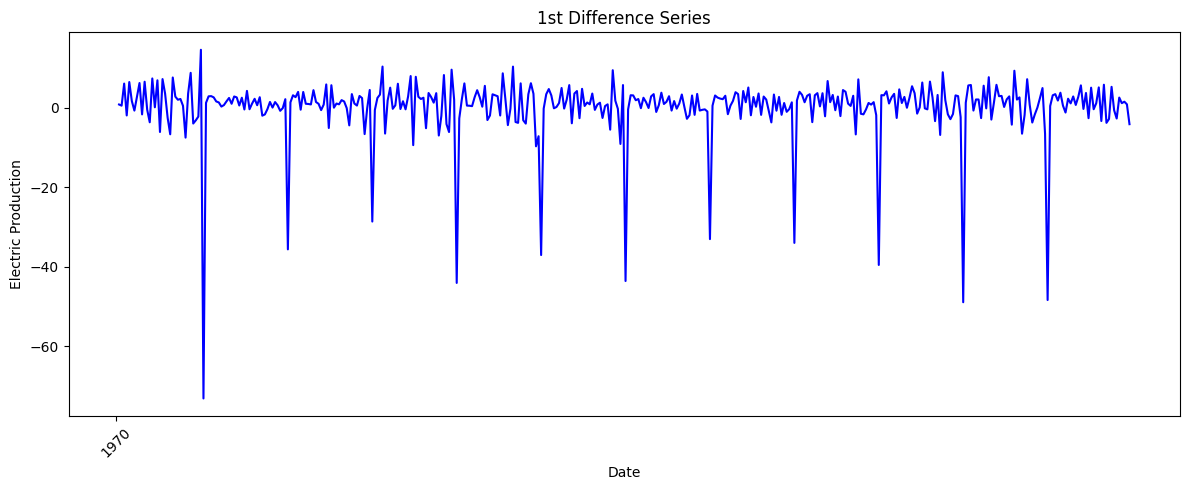

Results for 1st Difference Series:
ADF TEST:
  P-Value: 0.000000
  Verdict: STATIONARY
KPSS TEST:
  P-Value: 0.100000
  Verdict: STATIONARY
Phillips-Perron TEST:
  P-Value: 0.000000
  Verdict: STATIONARY


In [83]:
df1 = df.copy()
df1['IPG2211A2N'] = df1['IPG2211A2N'].diff()
df1 = df1.dropna(subset=['IPG2211A2N'])
run_stationary_suites(df1, '1st Difference')

c:\Users\Devank\Documents\Internship\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


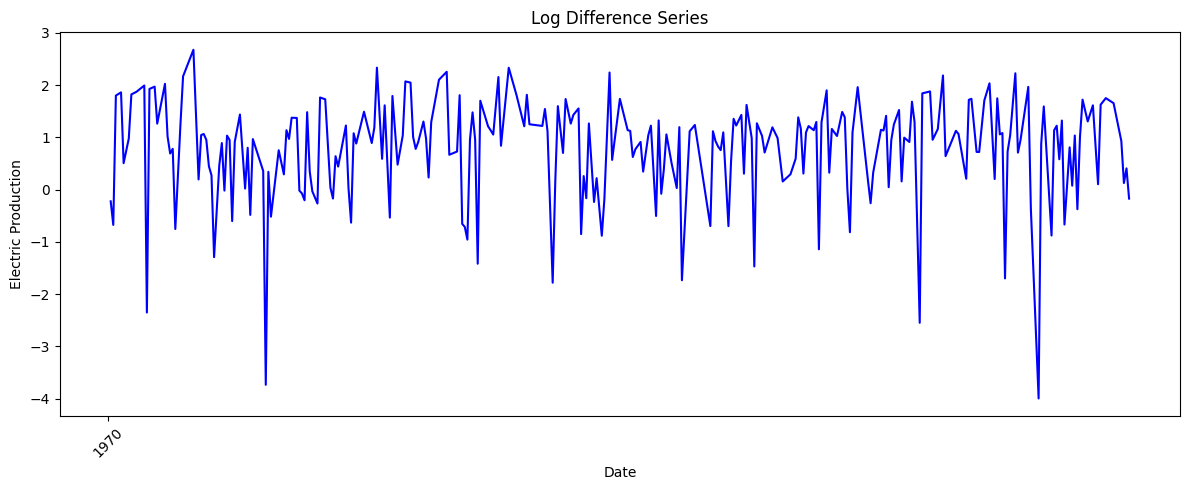

Results for Log Difference Series:
ADF TEST:
  P-Value: 0.000000
  Verdict: STATIONARY
KPSS TEST:
  P-Value: 0.100000
  Verdict: STATIONARY
Phillips-Perron TEST:
  P-Value: 0.000000
  Verdict: STATIONARY


In [84]:
df2= df1.copy()
df2['IPG2211A2N'] = np.log(df2['IPG2211A2N'])
df2 = df2.dropna(subset=['IPG2211A2N'])
run_stationary_suites(df2, 'Log Difference')